In [34]:
import os
import requests
import pandas as pd
import matplotlib.pyplot as plt
import math
import tiktoken
import torch
import torch.nn as nn

In [35]:
# Hyperparameters
batch_size = 4  # 每次训练时使用的数据批量大小 4x16=64
context_length = 16  # 每个输入序列的最大 token 长度
d_model = 64  # Transformer embedding 维度（每个 token 的向量表示大小） 64x1的vector 
num_layers = 8  # Transformer 堆叠的层数（决定模型深度） 8个transformer层
num_heads = 4  # 多头注意力机制（Multi-Head Attention） 中的注意力头数 # 我们的代码中通过 d_model / num_heads = 来获取 head_size
learning_rate = 1e-3  # 0.001 学习率，决定模型更新权重的步长
dropout = 0.1 # Dropout 比例，用于防止过拟合
max_iters = 500  # 训练的最大迭代次数
eval_interval = 50  # 多少次迭代后评估模型
eval_iters = 20  # How many iterations to average the loss over when evaluating the model 评估模型时取的平均损失计算次数
# macOS 下使用 
device = 'mps' if torch.backends.mps.is_available() else 'cpu'  # 运行设备，若 GPU 可用则使用 'mps'，否则使用 'cpu'
print(f"Using device: {device}")
# Windows / Linux 下使用 
#device = 'cuda' if torch.cuda.is_available() else 'cpu'  # 运行设备，若 GPU 可用则使用 'cuda'，否则使用 'cpu'

TORCH_SEED = 1337 # 设置随机种子，保证每次运行结果一致
torch.manual_seed(TORCH_SEED) # 设置 PyTorch 随机种子

Using device: cpu


In [36]:
# 读取文本数据
with open('./sales_textbook.txt', 'r', encoding='utf-8') as f:
    text = f.read()
print(text[0:100])

Chapter 1: Building Rapport and Capturing Attention
Subpoint: Understanding the Importance of Buildi


### tokenizer 分词

In [37]:
# Using TikToken to tokenize the source text  使用 tiktoken 进行分词
encoding = tiktoken.get_encoding("cl100k_base")
tokenized_text = encoding.encode(text) # OpenAI的网站示例，将文本转换为 token ID 序列（一个 token 对应一个整数）
print(type(tokenized_text))
tokenized_text = torch.tensor(tokenized_text, dtype=torch.long, device=device) # token ID 序列转换为张量
print(type(tokenized_text))
print(tokenized_text.shape)
max_token_value = tokenized_text.max().item() # 获取 token ID 中的 最大值，这对词汇表大小和embedding维度设计很重要

print(f"Tokenized text size: {len(tokenized_text)}")
print(f"The maximum value in the tokenized text is: {max_token_value}")
encoding.decode([100069]) # 最大tokenID对应的词汇 Clar 

<class 'list'>
<class 'torch.Tensor'>
torch.Size([77919])
Tokenized text size: 77919
The maximum value in the tokenized text is: 100069


'Clar'

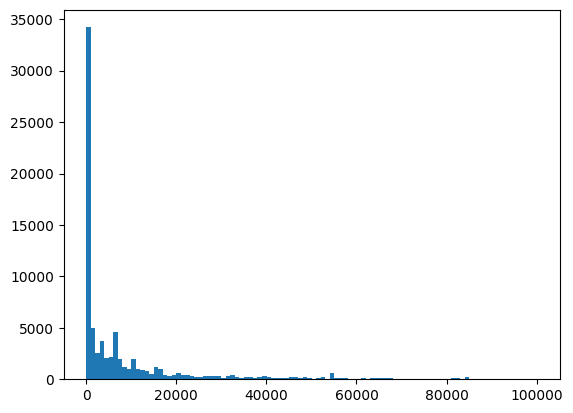

In [38]:
# 直方图统计了一下词频分布 越小的ID词频越高
plt.hist(tokenized_text.cpu().numpy(), bins=100)
plt.show()

In [39]:
# Split train and validation 划分训练集和验证集
split_idx = int(len(tokenized_text) * 0.9) # 前90% 作为训练集，10% 作为验证集 切片
train_data = tokenized_text[:split_idx] # 训练集
val_data = tokenized_text[split_idx:] # 验证集

In [40]:
# Prepare data for training batch 生成训练批次
data = train_data
idxs = torch.randint(low=0, high=len(data) - context_length, size=(batch_size,)) #从 train_data 中 随机选择 batch_size 个 batch 位置，生成训练输入
print("idxs:",idxs)

x_batch = torch.stack([data[idx:idx + context_length] for idx in idxs]) # 构造 x_batch（输入）
y_batch = torch.stack([data[idx + 1:idx + context_length + 1] for idx in idxs]) # 构造 y_batch（目标输出）
print(x_batch.shape, y_batch.shape)
print(x_batch.data)
print(y_batch.data) # 是 右移一位的 x_batch，表示 下一步预测的目标

#[encoding.decode([i]) for i in x_batch[0]],[encoding.decode([i]) for i in y_batch[0]]

idxs: tensor([35754, 55550, 63572,  1447])
torch.Size([4, 16]) torch.Size([4, 16])
tensor([[  279,  6763,  1920,    13,   578,  5845,   311, 13750, 19570,   279,
           907,   323,  7720,   315,  1057,  3956],
        [ 3495, 14955,    11,   477,  5064, 23146,   430,  9788,   279, 66732,
           315,   701, 10209,    13,  3296, 32644],
        [38769, 10742,    11, 20958,   264,  6928, 19451,    11, 11125, 64784,
            11,   323, 56501, 54111,   439,  6975],
        [43496,   872,  8830,   719,  1101,  3727,   279,  6130,  2733,  6755,
           323, 16365,   627, 29831, 19682,  5900]])
tensor([[ 6763,  1920,    13,   578,  5845,   311, 13750, 19570,   279,   907,
           323,  7720,   315,  1057,  3956,   477],
        [14955,    11,   477,  5064, 23146,   430,  9788,   279, 66732,   315,
           701, 10209,    13,  3296, 32644,  1521],
        [10742,    11, 20958,   264,  6928, 19451,    11, 11125, 64784,    11,
           323, 56501, 54111,   439,  6975, 10708],

In [41]:
encoding.decode([11])

','

In [42]:
# Illustration purpose 数据可视化-更方便看
pd.set_option('display.expand_frame_repr', False) #Pandas 显示完整的一行数据
print("Our batches:\n", pd.DataFrame(x_batch.detach().cpu().numpy())) #detach分离梯度.cpu().numpy()
print([encoding.decode([i]) for i in x_batch[0]])

Our batches:
       0      1     2      3     4      5      6      7      8      9    10     11     12     13     14     15
0    279   6763  1920     13   578   5845    311  13750  19570    279  907    323   7720    315   1057   3956
1   3495  14955    11    477  5064  23146    430   9788    279  66732  315    701  10209     13   3296  32644
2  38769  10742    11  20958   264   6928  19451     11  11125  64784   11    323  56501  54111    439   6975
3  43496    872  8830    719  1101   3727    279   6130   2733   6755  323  16365    627  29831  19682   5900
[' the', ' sales', ' process', '.', ' The', ' ability', ' to', ' effectively', ' communicate', ' the', ' value', ' and', ' benefits', ' of', ' our', ' products']


### Token Embedding 词向量嵌入

In [43]:
# Define Token Embedding look-up table
token_embedding_lookup_table = nn.Embedding(max_token_value+1, d_model).to(device) #1D-2D 的一个2D字典，gpt3 使用的是50257 * 12288
print("Token Embedding Look-up table: ", token_embedding_lookup_table)

#离散 token（整数索引）转换成连续的高维向量（d_model维），神经网络无法直接处理这些离散的整数索引
#这些向量经过训练后（在后面），能捕获语义信息和词汇之间的关系

Token Embedding Look-up table:  Embedding(100070, 64)


In [44]:
#查看某个 token 的嵌入向量
print(data[61650], encoding.decode([data[61650]])) # 61650 是 token ID
_ = token_embedding_lookup_table(data[61650]) #查询 token ID 为 61650 的 token 的嵌入向量
pd.set_option('expand_frame_repr', True) # 设置 pandas 显示选项
print(pd.DataFrame(_.detach().cpu().numpy())) # 显示嵌入向量
print(token_embedding_lookup_table.weight) # 查看整个嵌入向量表，获取所有词嵌入矩阵的权重。
print(token_embedding_lookup_table.weight.shape) # 100069+1 个 token 的嵌入向量，每个向量的维度为 64

tensor(907)  value
           0
0   0.370826
1   0.272521
2  -1.915345
3   0.032303
4   0.017929
..       ...
59  1.097342
60  0.231425
61  0.104482
62 -1.583871
63  1.481635

[64 rows x 1 columns]
Parameter containing:
tensor([[ 0.6258,  0.0255,  0.9545,  ...,  1.4738,  0.0688,  1.3327],
        [-0.4970,  0.4658, -0.2573,  ..., -0.6939, -0.3252,  1.2439],
        [ 1.3471,  1.6910, -0.1244,  ..., -0.9786, -0.4320, -1.4938],
        ...,
        [ 0.1471,  0.5790, -0.6682,  ..., -1.0645,  1.2904, -1.1105],
        [ 0.4153, -0.3456,  0.4415,  ...,  1.3334,  0.3723,  0.7225],
        [ 1.9651, -0.6380, -1.3955,  ...,  0.0445,  0.8359, -0.7229]],
       requires_grad=True)
torch.Size([100070, 64])


In [45]:
# Get x and y embedding 计算批次的嵌入向量？？
x_batch_embedding = token_embedding_lookup_table(x_batch.detach().to(device)) # [4, 16, 64] [batch_size, context_length, d_model] 
y_batch_embedding = token_embedding_lookup_table(y_batch.detach().to(device))

print(x_batch_embedding.shape, y_batch_embedding.shape) #[4, 16, 64]
print(pd.DataFrame(x_batch_embedding[0].detach().cpu().numpy())) # 显示第一个批次（16个Token）的嵌入向量
print(pd.DataFrame(y_batch_embedding[0].detach().cpu().numpy()))


torch.Size([4, 16, 64]) torch.Size([4, 16, 64])
          0         1         2         3         4         5         6   \
0   1.399742 -1.206918  0.327990 -0.251130  0.531874 -0.248193  0.351938   
1   0.566486 -1.102276  1.712332 -0.354509  0.550577 -0.707943 -0.743899   
2  -0.426478  1.717362 -0.343810 -0.917124 -0.273610  0.695366 -0.849842   
3   0.709939  1.369311 -0.707588  1.538689 -2.110915  0.441344 -0.005807   
4  -1.963246  0.298927  0.131364  0.082995  0.153765 -0.821641 -1.220109   
5   0.811149  0.435134  1.131030  0.816734 -1.013971 -0.052429 -0.527541   
6   0.317549  2.106441 -0.092210  0.636316 -0.912476 -1.975633 -0.068806   
7  -2.025703  1.256391 -0.318619  1.432163  1.644837 -1.910154 -1.001209   
8   2.906978  0.092020 -0.785242  0.609121 -0.790180 -0.026004 -1.156866   
9   1.399742 -1.206918  0.327990 -0.251130  0.531874 -0.248193  0.351938   
10  0.370826  0.272521 -1.915345  0.032303  0.017929 -1.451397 -1.632907   
11 -0.030617  0.305096 -0.199683  1.0218

### 位置编码 Position Encoding PE

In [46]:
# Define Position Encoding look-up table 定义位置编码查找表 
context_length = 16
position_encoding_lookup_table = torch.zeros(context_length, d_model) #这个生成了一个全0tensor
position = torch.arange(0, context_length, dtype=torch.float).unsqueeze(1) # 生成了一个按自然数的序列 0-15，unsqueeze(1)是为了增加维度
print(position.shape) # [16, 1] 16个位置，1个维度 

#参考PE公式 
div_term = torch.exp(torch.arange(0, d_model, 2).float() * (- math.log(10000) / d_model))  #10000^(-i/d_model) 控制衰减速度 
#div_term_ = 1/(10000 ** (torch.arange(0, d_model, 2).float()/d_model)) #与上面完全等价
print(div_term.shape) # [32] 32个维度

position*div_term # 16*32

position_encoding_lookup_table[:, 0::2] = torch.sin(position * div_term) # sin 作用在 偶数索引维度（0,2,4,...）
position_encoding_lookup_table[:, 1::2] = torch.cos(position * div_term) # cos 作用在 奇数索引维度（1,3,5,...）

##为什么使用 sin 和 cos？
#周期性：不同长度的序列仍然能有相似的模式。
#平滑变化：相近的 token 编码相似，帮助模型学习顺序关系。

# position / embedding里面的index 注意区分 PE公式的i是embedding的index

position_encoding_lookup_table = position_encoding_lookup_table.unsqueeze(0).expand(batch_size, -1, -1) #add batch dimension
#unsquezze 0： 在第0维增加一个batch维度 ，expand 创建了一个广播，expand里面 -1 表示这些维度保持原样
#每个样本序列（Batch）都需要一个相同的 Positional Encoding

print("Position Encoding Look-up Table: ", position_encoding_lookup_table.shape) # [4, 16, 64] [batch_size, context_length, d_model]
# 结果：[4, 16, 64]，表示：4：batch_size 16：上下文窗口大小 64：嵌入维度 一个token是64个数来对应他的
pd.DataFrame(position_encoding_lookup_table[0].detach().cpu().numpy())


torch.Size([16, 1])
torch.Size([32])
Position Encoding Look-up Table:  torch.Size([4, 16, 64])


,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
0,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,...,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000
1,0.841471,0.540302,0.681561,0.731761,0.533168,0.846009,0.409309,0.912396,0.310984,0.950415,...,0.000422,1.000000,0.000316,1.000000,0.000237,1.000000,0.000178,1.000000,0.000133,1.000000
2,0.909297,-0.416147,0.997480,0.070948,0.902131,0.431463,0.746903,0.664932,0.591127,0.806578,...,0.000843,1.000000,0.000632,1.000000,0.000474,1.000000,0.000356,1.000000,0.000267,1.000000
3,0.141120,-0.989992,0.778273,-0.627927,0.993253,-0.115966,0.953634,0.300967,0.812649,0.582754,...,0.001265,0.999999,0.000949,1.000000,0.000711,1.000000,0.000533,1.000000,0.000400,1.000000
4,-0.756802,-0.653644,0.141539,-0.989933,0.778472,-0.627680,0.993281,-0.115730,0.953581,0.301137,...,0.001687,0.999999,0.001265,0.999999,0.000949,1.000000,0.000711,1.000000,0.000533,1.000000
5,-0.958924,0.283662,-0.571127,-0.820862,0.323935,-0.946079,0.858896,-0.512150,0.999947,-0.010342,...,0.002108,0.999998,0.001581,0.999999,0.001186,0.999999,0.000889,1.000000,0.000667,1.000000
6,-0.279415,0.960170,-0.977396,-0.211416,-0.230368,-0.973104,0.574026,-0.818837,0.947148,-0.320796,...,0.002530,0.999997,0.001897,0.999998,0.001423,0.999999,0.001067,0.999999,0.000800,1.000000
7,0.656987,0.753902,-0.859313,0.511449,-0.713721,-0.700430,0.188581,-0.982058,0.800422,-0.599437,...,0.002952,0.999996,0.002214,0.999998,0.001660,0.999999,0.001245,0.999999,0.000933,1.000000
8,0.989358,-0.145500,-0.280228,0.959933,-0.977262,-0.212036,-0.229904,-0.973213,0.574318,-0.818632,...,0.003374,0.999994,0.002530,0.999997,0.001897,0.999998,0.001423,0.999999,0.001067,0.999999
9,0.412118,-0.911130,0.449194,0.893434,-0.939824,0.341660,-0.608108,-0.793854,0.291259,-0.956644,...,0.003795,0.999993,0.002846,0.999996,0.002134,0.999998,0.001600,0.999999,0.001200,0.999999


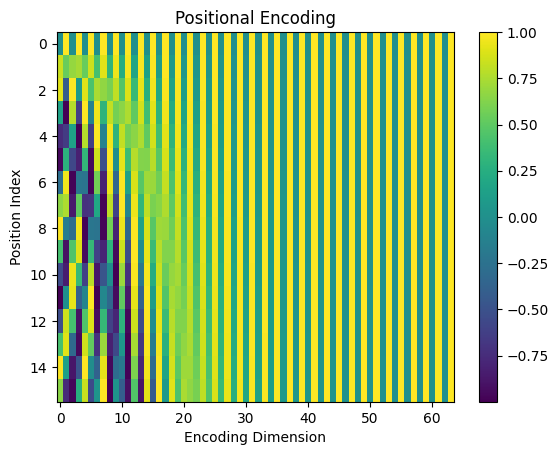

In [47]:
# Illustration Purpose Only 可视化位置编码
def visualize_pe(pe):
    plt.imshow(pe, aspect="auto")
    plt.title("Positional Encoding")
    plt.xlabel("Encoding Dimension")
    plt.ylabel("Position Index")
    plt.colorbar()
    plt.show()

position_encoding_lookup_table2_np = position_encoding_lookup_table[0].cpu().numpy() 
visualize_pe(position_encoding_lookup_table2_np)

#显示位置编码矩阵，X 轴是 编码维度，Y 轴是 位置索引。
#颜色深浅表示数值大小，不同行的编码不同，说明不同位置的信息是唯一的。



In [48]:
# Add positional encoding into the input embedding vector 计算最终的输入向量 把位置编码加入嵌入向量
input_embedding_x = x_batch_embedding + position_encoding_lookup_table.to(device) # [4, 16, 64] [batch_size, context_length, d_model]
input_embedding_y = y_batch_embedding + position_encoding_lookup_table.to(device)
pd.DataFrame(input_embedding_x[0].detach().cpu().numpy()) #第一批次的嵌入矩阵。

# 为什么直接相加？
# 位置编码和词嵌入维度相同（d_model）。
# 这样模型能在训练时 同时学习语义和位置信息。
# 位置编码的数值较小，不会掩盖原始 token 信息。


# RNN 有 序列信息，但 Transformer 是 并行计算，必须手动加上位置信息。
# 两种方法：
# 训练一个 可学习的位置编码（如 GPT）。
# 使用 固定的 sin/cos 位置编码（如原始 Transformer）。

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
0,1.399742,-0.206918,0.327990,0.748870,0.531874,0.751807,0.351938,0.610762,0.129977,-0.207580,...,-0.547752,2.515671,1.223743,1.833670,-0.404194,1.563555,0.591292,0.275255,1.670105,0.758279
1,1.407957,-0.561974,2.393893,0.377252,1.083746,0.138066,-0.334590,1.670161,0.329176,2.342795,...,0.873984,2.226714,0.794747,1.598629,0.884658,1.032520,1.353795,1.059697,1.172643,1.527427
2,0.482819,1.301215,0.653670,-0.846175,0.628521,1.126829,-0.102938,-0.636202,0.428573,0.553769,...,-0.934116,2.145729,-1.913517,0.552654,0.597746,2.673483,-1.969119,1.397835,-0.438208,0.437077
3,0.851059,0.379319,0.070685,0.910763,-1.117662,0.325378,0.947827,0.472564,0.516017,0.790074,...,0.072798,0.264451,0.070916,-1.744750,1.088080,0.002188,0.715526,-0.357311,1.604357,1.920290
4,-2.720048,-0.354717,0.272903,-0.906938,0.932237,-1.449321,-0.226828,-1.203768,2.488952,2.130765,...,0.533600,0.432145,-2.389682,0.913403,0.066965,1.655225,0.625080,0.236625,-0.692241,0.992275
5,-0.147775,0.718796,0.559903,-0.004127,-0.690035,-0.998508,0.331355,-1.222723,0.836060,-1.353497,...,-0.044886,-0.201054,-0.926252,1.322522,0.587324,1.108183,-1.652407,2.918813,0.942309,1.584330
6,0.038134,3.066611,-1.069607,0.424900,-1.142844,-2.948736,0.505219,-0.617680,1.280667,-0.168857,...,0.202646,1.051821,1.306703,1.517673,0.050767,1.044631,1.347860,0.678610,-0.477987,0.833080
7,-1.368717,2.010294,-1.177933,1.943613,0.931115,-2.610583,-0.812628,-1.958096,2.302625,0.242536,...,-2.336618,1.190780,-0.052987,3.281737,-0.415515,0.198294,-1.392472,2.863094,-0.392633,0.868254
8,3.896336,-0.053480,-1.065470,1.569054,-1.767442,-0.238040,-1.386770,-0.574759,0.118923,-1.069920,...,3.366446,0.203255,1.759607,2.526687,-0.652322,2.660683,0.966853,1.618786,1.664013,2.768385
9,1.811860,-2.118048,0.777184,0.642304,-0.407949,0.093468,-0.256171,-1.183092,0.421236,-2.164224,...,-0.543957,2.515664,1.226589,1.833666,-0.402059,1.563552,0.592893,0.275254,1.671305,0.758279


### 多头注意力

In [49]:
# Prepare Query, Key, Value for Multi-head Attention
X = input_embedding_x
query = key = value = X # [4, 16, 64] [batch_size, context_length, d_model]
query.shape

torch.Size([4, 16, 64])

In [50]:
# Query（查询）、Key（键）、Value（值） 都等于输入。
# Query 决定当前 token 想关注什么。
# Key 决定每个 token 能提供什么信息。
# Value 决定每个 token 的具体信息内容。

In [51]:
# Define Query, Key, Value weight matrices #GPT3 在这个地方是12228*12228*3 
#Wq、Wk、Wv 分别是 Query, Key, Value 的 线性变换矩阵。
Wq = nn.Linear(d_model, d_model).to(device) # 64,64 
Wk = nn.Linear(d_model, d_model).to(device)
Wv = nn.Linear(d_model, d_model).to(device)

Q = Wq(query).to(device) #[4, 16, 64] 线性变换/线性投影
Q = Q.view(batch_size, -1, num_heads, d_model // num_heads)  #[4, 16, 4, 16] 拆分Q到多个头 学习不同的信息

K = Wk(key).to(device) #[4, 16, 64]
K = K.view(batch_size, -1, num_heads, d_model // num_heads)  #[4, 16, 4, 16]

V = Wv(value).to(device)#[4, 16, 64]
V = V.view(batch_size, -1, num_heads, d_model // num_heads)  #[4, 16, 4, 16]

#打印一下数据看看 
# print(torch.round(Q[0] * 100) / 100) 
# qqq = Q.detach().cpu().numpy()
# pd.set_option('expand_frame_repr', False)
# for qs in qqq:
#     for qss in qs:
#         print(pd.DataFrame(qss))

# print(Q.shape) # [4, 16, 4, 16] [batch_size, context_length, num_heads, head_size]

# 只打印前 2 个 batch，前 5 个 token
N_batch = 2
N_seq = 5

qqq = Q.detach().cpu().numpy()
pd.set_option('expand_frame_repr', False)

for i, qs in enumerate(qqq[:N_batch]):  # 限制 batch 维度
    print(f"\n==== Batch {i} ====")
    for j, qss in enumerate(qs[:N_seq]):  # 限制 seq_len 维度
        print(f"\nToken {j} Attention Heads:\n", pd.DataFrame(qss))

print("\nQ.shape:", Q.shape)


==== Batch 0 ====

Token 0 Attention Heads:
          0         1         2         3         4         5         6         7         8         9         10        11        12        13        14        15
0  0.843055 -0.550052 -0.127732 -0.844840 -0.819225  0.063522 -0.187879  1.182711 -1.542636  0.582238  0.123996 -0.023149  0.141312  0.812356 -1.628145  0.312126
1 -0.350486  0.484634 -0.140094  0.746821  1.481563 -0.266805  0.312059 -0.710153 -0.557109  0.462987 -0.575465  0.824084 -0.910005 -0.060633 -0.851140 -0.696344
2 -0.140998 -0.055692 -0.718412 -0.797249  0.366570  1.513673  0.577341 -0.707247 -0.275017  1.270264 -0.846118 -1.158900  1.652279  0.261800 -0.884520 -0.846511
3 -0.244500  0.759894  0.067822  0.388658 -0.178537  1.044808 -0.276759 -0.887757 -0.158977 -0.619547 -0.298364 -0.604880 -1.250720  0.388842 -1.088377  0.081781

Token 1 Attention Heads:
          0         1         2         3         4         5         6         7         8         9         10      

In [52]:
# Transpose q,k,v from [batch_size, context_length, num_heads, head_size] to [batch_size, num_heads, context_length, head_size]
# The reason is that treat each batch with "num_heads" as its first dimension. 重新排列张量 Q, K, V 的维度，使其更适合并行计算
# 交换前[batch_size, seq_len, num_heads, head_size] =[4,16,4,16] 交换后 [batch_size, num_heads, seq_len, head_size] = [4,4,16,16]
Q = Q.transpose(1, 2) # [4, 4, 16, 16]
K = K.transpose(1, 2) # [4, 4, 16, 16]
V = V.transpose(1, 2) # [4, 4, 16, 16]

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,0.827912,0.872087,0.805252,0.638937,0.403635,-0.220579,0.074281,0.066307,0.161097,0.776864,-0.015753,0.059171,-0.167397,-0.519080,-0.113654,0.370162
1,1.123528,0.464093,0.514921,-0.184883,0.292599,-0.127225,0.205937,0.207777,0.602376,1.016719,0.158707,0.074483,0.526718,0.460966,0.633765,0.534267
2,1.040623,0.605708,0.119165,-0.133348,-0.169015,-0.146091,0.444743,0.050206,0.774002,0.830742,-0.216136,-0.111672,0.751038,0.496729,0.747770,0.609336
3,0.900045,0.596818,0.359724,0.836026,0.074438,0.652813,1.057635,-0.026944,1.124048,0.971823,-0.467323,-0.247706,0.002623,-0.360195,0.017813,0.965252
4,1.061119,1.158659,0.633724,-0.320907,0.383561,-0.448183,-0.238576,-0.078154,-0.033891,0.852194,0.056048,0.533376,0.968322,0.675573,0.506570,0.651593
5,0.071058,0.273445,0.044782,0.250272,-0.114290,0.121239,0.472959,0.086112,-0.077087,-0.158122,-0.416886,0.212225,0.220158,-0.492304,0.175022,0.505993
6,0.897961,1.322748,0.553525,0.079147,0.502846,-0.506932,0.223247,-0.400829,0.203914,0.658943,-0.018270,0.620022,0.600703,0.066074,0.316328,0.332746
7,0.025299,0.779429,0.627483,-0.354743,0.218848,-0.055096,0.297431,-0.119230,-0.025749,0.031660,0.079259,0.274235,0.095197,-0.625557,-0.000797,0.226548
8,0.529123,-0.196815,0.232964,0.031045,0.214278,-0.328799,-0.685732,0.060671,0.237945,0.642808,0.532076,0.191681,-0.066689,0.383821,-0.080174,0.330104
9,0.935247,0.690427,0.511019,1.063499,0.504674,-0.227777,-0.035515,-0.006277,0.174739,0.899135,0.184269,0.238904,-0.084467,-0.414828,-0.173580,0.431657


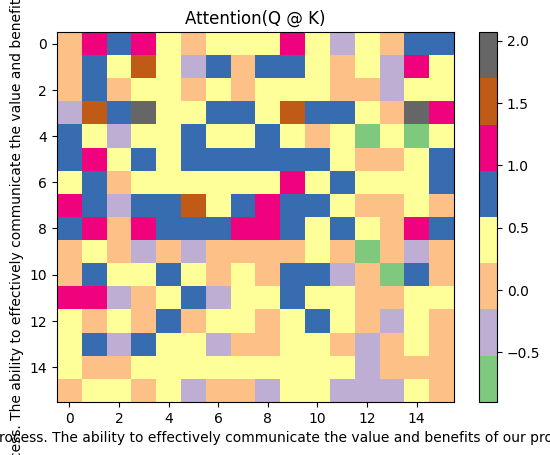

In [53]:
# Calculate the attention score 计算注意力得分
attention_score = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_model // num_heads) # [4, 4, 16, 16]

#[batch_size, num_heads, seq_len, head_size] @ [batch_size, num_heads, head_size, seq_len] = [batch_size, num_heads, seq_len, seq_len]
# Q @ K^T = [4, 4, 16, 16] @ [4, 4, 16, 16] = [4, 4, 16, 16]

# Attention（Q, K, V) = softmax(Q @ K / sqrt(d_k)) @ V
# 为什么除以 sqrt(d_k)？QK^T 计算时，每个 head_size 维度的元素相加，数值容易变大（类似矩阵点积）。避免 QK^T 结果数值过大，导致梯度消失问题。
# 如果 QK^T 数值过大，softmax(QK^T) 输出接近 one-hot，梯度消失（梯度消失问题）


# Illustration only 可视化注意力分数
plt.imshow(attention_score[1, 1].detach().cpu().numpy(), "Accent", aspect="auto")
plt.title("Attention(Q @ K)") #plot attention in the first head of the first batch
plt.xlabel(encoding.decode(x_batch[0].tolist()))
plt.ylabel(encoding.decode(x_batch[0].tolist()))
plt.colorbar()
pd.DataFrame(attention_score[0][0].detach().cpu().numpy())

# 生成 注意力矩阵（attention map），查看不同 token 之间的注意力分布。
#图里面代表什么？

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,0.827912,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf
1,1.123528,0.464093,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf
2,1.040623,0.605708,0.119165,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf
3,0.900045,0.596818,0.359724,0.836026,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf
4,1.061119,1.158659,0.633724,-0.320907,0.383561,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf
5,0.071058,0.273445,0.044782,0.250272,-0.114290,0.121239,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf
6,0.897961,1.322748,0.553525,0.079147,0.502846,-0.506932,0.223247,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf
7,0.025299,0.779429,0.627483,-0.354743,0.218848,-0.055096,0.297431,-0.119230,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf
8,0.529123,-0.196815,0.232964,0.031045,0.214278,-0.328799,-0.685732,0.060671,0.237945,-inf,-inf,-inf,-inf,-inf,-inf,-inf
9,0.935247,0.690427,0.511019,1.063499,0.504674,-0.227777,-0.035515,-0.006277,0.174739,0.899135,-inf,-inf,-inf,-inf,-inf,-inf


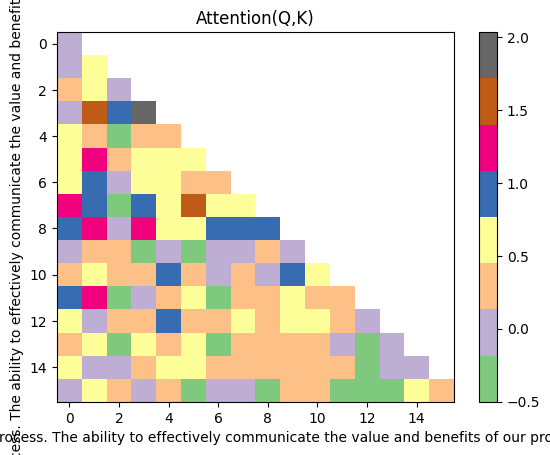

In [54]:
# Apply Mask to attention scores 添加 Mask（掩码）
attention_score = attention_score.masked_fill(torch.triu(torch.ones(attention_score.shape[-2:]).to(device), diagonal=1).bool(), float('-inf'))#[4, 4, 16, 16] [batch_size, num_heads, context_length, context_length]
# Transformer 进行 自回归（auto-regressive） 预测时，不能看到未来的信息。
# torch.triu() 创建 上三角矩阵，填充 -inf，Softmax之后就为0，保证只能关注当前及之前的 token。

# Illustration only
plt.imshow(attention_score[1, 1].detach().cpu().numpy(), "Accent", aspect="auto")
plt.title("Attention(Q,K)")
plt.xlabel(encoding.decode(x_batch[0].tolist()))
plt.ylabel(encoding.decode(x_batch[0].tolist()))
plt.colorbar()
pd.DataFrame(attention_score[0][0].detach().cpu().numpy())

In [55]:
# Softmax the attention score 归一化注意力分数
# 每个 token（query）对其他 token（key）的关注程度。
attention_score = torch.softmax(attention_score, dim=-1) #[4, 4, 16, 16] [batch_size, num_heads, context_length, context_length]
pd.DataFrame(attention_score[0][0].detach().cpu().numpy())


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.659133,0.340867,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.488936,0.316498,0.194566,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.306845,0.226584,0.178756,0.287816,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.284609,0.313769,0.185624,0.071457,0.144541,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,0.159313,0.195051,0.155182,0.190583,0.132360,0.167512,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,0.195804,0.299437,0.138751,0.086341,0.131894,0.048049,0.099724,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,0.100501,0.213640,0.183524,0.068726,0.121962,0.092737,0.131933,0.086976,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,0.176701,0.085500,0.131407,0.107381,0.128974,0.074929,0.052436,0.110609,0.132063,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,0.148425,0.116194,0.097110,0.168735,0.096496,0.046389,0.056222,0.057891,0.069378,0.143160,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [57]:
!pip install bertviz

   ---------------------------------------- 0.0/12.0 MB ? eta -:--:--
   --- ------------------------------------ 1.0/12.0 MB 7.1 MB/s eta 0:00:02
   ------------ --------------------------- 3.7/12.0 MB 9.9 MB/s eta 0:00:01
   -------------------- ------------------- 6.0/12.0 MB 10.5 MB/s eta 0:00:01
   ---------------------------- ----------- 8.7/12.0 MB 11.0 MB/s eta 0:00:01
   ---------------------------------- ----- 10.2/12.0 MB 10.4 MB/s eta 0:00:01
   ---------------------------------------  11.8/12.0 MB 10.0 MB/s eta 0:00:01
   ---------------------------------------  11.8/12.0 MB 10.0 MB/s eta 0:00:01
   ---------------------------------------  11.8/12.0 MB 10.0 MB/s eta 0:00:01
   ---------------------------------------  11.8/12.0 MB 10.0 MB/s eta 0:00:01
   ---------------------------------------  11.8/12.0 MB 10.0 MB/s eta 0:00:01
   ---------------------------------------  11.8/12.0 MB 10.0 MB/s eta 0:00:01
   ---------------------------------------  11.8/12.0 MB 10.0 MB/s 

In [58]:
from bertviz import head_view

att_first_head = [attention_score[i].unsqueeze(0) for i in range(batch_size)]
print(att_first_head[0].shape)

token_list = [[encoding.decode_single_token_bytes(i).decode('utf-8')] for i in x_batch[0].tolist()]
head_view(att_first_head, token_list, prettify_tokens=False)

#可视化的演示了第一个 batch 的第一个头的注意力矩阵。
#图中的颜色越深，表示注意力分数越高。 左侧是输入的token，右侧是目标的token，注意力（Attention）权重影响的 Token，即当前 Token 在计算自注意力时，关注的内容。


torch.Size([1, 4, 16, 16])


<IPython.core.display.Javascript object>

In [59]:
# Calculate the V attention output 计算注意力加权输出
print(attention_score.shape) #[4, 4, 16, 16] [batch_size, num_heads, context_length, context_length]
print(V.shape) #[4, 4, 16, 16] [batch_size, num_heads, context_length, head_size]
A = torch.matmul(attention_score, V) # [4, 4, 16, 16] [batch_size, num_heads, context_length, head_size]
print(A.shape)

#A = attention_score @ V，将注意力分数 attention_score 作用于 V，获取最终的上下文表示。

torch.Size([4, 4, 16, 16])
torch.Size([4, 4, 16, 16])
torch.Size([4, 4, 16, 16])


In [61]:
# Concatenate the attention output 多头输出合并
A = A.transpose(1, 2) # [4, 16, 4, 16] [batch_size, context_length, num_heads, head_size]
A = A.reshape(batch_size, -1, d_model) # [4, 16, 64] [batch_size, context_length, d_model]
A.shape
#交换 num_heads 维度，重新 reshape 回 [batch_size, context_length, d_model]=[4,16,64]。

torch.Size([4, 16, 64])

In [62]:
# Define the output weight matrix   计算最终输出
Wo = nn.Linear(d_model, d_model).to(device) #投影层 
output = Wo(A) # [4, 16, 64] [batch_size, context_length, d_model] Wo 是最终的投影层，合并多头注意力:把 num_heads * head_size 变回 d_model。
print(output.shape)
pd.DataFrame(output[0].detach().cpu().numpy())

torch.Size([4, 16, 64])


,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
0,-0.137799,-0.196156,-0.329198,0.110896,-0.145731,-0.156281,-0.241270,-0.024793,0.331834,0.105654,...,-0.117504,0.151439,-0.178795,-0.244704,0.089554,0.139366,-0.070444,-0.181417,0.062844,-0.230334
1,-0.021681,-0.399201,-0.048724,-0.228915,-0.454176,0.073737,-0.345115,-0.274820,0.027087,0.118398,...,-0.035211,0.041359,-0.533481,-0.169772,-0.111060,-0.003374,-0.208540,-0.587489,0.354666,0.114030
2,-0.131468,0.100036,0.043589,0.227908,0.464717,0.400608,0.383066,-0.012695,-0.166129,0.082925,...,0.062031,-0.948210,0.283645,0.196154,-0.090542,0.072085,-0.229119,-0.216717,-0.415120,0.292871
3,-0.303003,-0.400856,-0.339191,-0.110398,-0.363733,-0.287233,-0.663293,-0.259874,-0.042978,0.409364,...,-0.274545,0.299658,-0.174182,0.317341,-0.102909,0.255056,-0.583849,-0.224683,0.237170,0.311816
4,0.094615,-0.110332,-0.175202,-0.212119,-0.114419,0.172464,0.055311,-0.106520,-0.057048,-0.086520,...,0.218047,-0.083633,-0.343673,-0.215142,0.123180,-0.041288,0.021315,-0.356591,-0.011291,-0.121476
5,0.362646,0.283429,-0.240820,-0.052891,-0.167232,0.236968,0.062940,0.285056,-0.521615,0.179585,...,-0.032416,-0.115698,0.100739,0.238753,0.375720,0.070738,0.199387,0.201531,-0.209099,0.261878
6,0.306534,0.085437,-0.231621,-0.302556,-0.527656,-0.107202,-0.339303,-0.061520,0.092981,0.026335,...,0.064005,0.723690,-0.543819,-0.518731,0.487474,-0.041086,0.198367,0.009162,0.412772,-0.176863
7,-0.037659,0.043811,-0.064202,0.061737,-0.061354,0.239527,0.169202,-0.061833,-0.100980,0.038084,...,0.023646,-0.401596,-0.092396,-0.154824,0.184923,-0.085335,-0.033754,-0.006420,-0.062967,-0.146996
8,0.438705,0.400155,-0.331143,-0.125576,-0.548831,0.126974,-0.275450,0.122247,-0.381318,0.373746,...,-0.256113,0.390767,-0.170401,-0.297738,0.338046,0.182476,0.324353,0.007989,0.054324,0.164141
9,0.609021,-0.064836,-0.129669,-0.613014,-0.584743,0.244454,-0.148897,-0.005832,-0.371328,-0.023906,...,0.202549,0.062383,-0.542463,-0.519453,0.375612,-0.450260,0.219857,-0.667942,-0.075209,-0.101881


In [63]:
# Add residual connection 残差连接
output = output + X # 直接加上输入 X，保持信息流动，防止梯度消失。直接把 output（多头注意力结果）和 X（原始输入）相加，保留输入信息。

### 层归一化

In [64]:
# Add Layer Normalization 层归一化 
# 标准化 d_model 维度的数据，使得均值接近 0，方差接近 1
layer_norm = nn.LayerNorm(d_model).to(device)
output_layernorm = layer_norm(output)

### FFN 全连接网络

In [65]:
# Define Feed Forward Network
output = nn.Linear(d_model, d_model * 4).to(device)(output_layernorm) #维度扩展 64->256
output = nn.ReLU()(output) #GPT2 使用的是GELU 激活函数
output = nn.Linear(d_model * 4, d_model).to(device)(output) #维度缩减 256->64
output = torch.dropout(output, p=dropout, train=True) #添加 dropout 防止过拟合

In [66]:
# Add residual connection & layerNorm (last time in a Transformer block) 残差连接 & 再次层归一化
output = output + output_layernorm
# Add Layer Normalization
layer_norm = nn.LayerNorm(d_model).to(device)
output = layer_norm(output)
print(output.shape)

torch.Size([4, 16, 64])


### 输出映射到词表

In [67]:
# Apply the final linear layer to get the logits 输出映射到词汇表
# 计算logits 预测下一个token
logits = nn.Linear(d_model, max_token_value+1).to(device)(output) #将 output 投影到词汇表大小（vocab_size），计算每个 token 的概率。 
pd.DataFrame(logits[0].detach().cpu().numpy())

,0,1,2,3,4,5,6,7,8,9,...,100060,100061,100062,100063,100064,100065,100066,100067,100068,100069
0,-0.044809,-0.222266,-0.517243,-0.491910,0.131247,0.259880,-0.847565,-0.239914,-0.404171,-0.409098,...,-0.007433,0.473091,0.769178,0.338749,0.902008,-0.654052,-0.045166,-0.552212,-0.183128,-0.480121
1,0.050633,0.585980,-0.824935,-0.736383,-0.198590,-0.127693,-0.118646,-0.728139,0.171528,-0.738513,...,0.636206,0.171920,-1.005566,-0.725265,0.888274,-0.579370,0.364705,0.560597,-0.627994,0.603663
2,0.190047,0.132673,0.076559,-0.336921,0.062474,-0.736158,0.311225,-0.354202,0.068271,-0.995199,...,0.263334,0.083524,0.054028,-0.361724,0.773397,-0.460687,-0.505273,-0.488471,-0.740181,-0.220124
3,0.155820,0.457364,0.547529,0.252701,-0.389852,0.309129,-0.770133,-0.359118,-1.483866,-1.384191,...,-1.021985,1.192765,-0.188229,-0.559786,1.143165,-0.378925,0.472500,1.029683,-0.174860,0.429112
4,-0.096338,-0.484179,-0.023336,-0.884573,0.069793,-0.561575,0.246348,-0.230492,0.077513,-0.301357,...,-0.083665,0.204563,-0.749987,1.743172,0.430957,-0.677125,0.937196,-1.845333,-1.310315,0.189848
5,-0.411795,-0.146455,-1.442477,0.354608,-0.393536,-0.489877,-0.710878,0.368259,0.318443,-0.641755,...,-0.723787,0.581751,0.940184,0.150801,-0.431445,-0.491181,1.005785,-0.573151,0.624229,0.376931
6,-0.033376,0.160396,-0.802590,0.005679,0.477372,-0.029671,-1.108919,-0.439074,-0.563320,-0.621852,...,-0.401963,0.698619,0.125582,-0.570359,-0.124358,-0.348988,0.393878,-0.449560,0.300212,-0.220864
7,0.829598,0.216430,0.246587,0.363116,-0.095387,0.020545,-0.598040,0.737623,0.462634,0.274665,...,0.307743,0.318851,-0.070388,0.021489,0.347662,-0.228681,1.028933,0.632782,0.067514,0.190281
8,0.297622,0.062638,-0.585310,0.042978,0.497621,-0.218077,-0.840485,0.538718,-0.322479,-0.950044,...,-1.207284,-0.050387,0.424971,-0.101225,0.052449,-0.134275,-0.066523,-0.333447,1.561779,-0.071186
9,0.314500,-0.064195,-0.580978,-0.411791,0.724699,-0.537064,-0.804726,0.366609,-0.681461,-0.708746,...,0.036632,0.310544,0.333012,0.511166,0.567238,-0.553166,-0.089129,-0.932765,-0.292382,-0.136019


In [68]:
# Get the probabilities  计算概率分布
# torch.softmax usually used during inference, during training we use torch.nn.CrossEntropyLoss
# but for illustration purpose, we'll use torch.softmax here
probabilities = torch.softmax(logits, dim=-1)
pd.DataFrame(probabilities[0].detach().cpu().numpy())
probabilities.shape

torch.Size([4, 16, 100070])

In [69]:
# Let's see the predicted token and it's original English word 预测下一个 Token
predicted_index = torch.argmax(probabilities[0,0]).item()
encoding.decode([predicted_index])

'umbai'

In [70]:
# Let's see the original input sentence
print(encoding.decode(x_batch[0].tolist()))
print(encoding.decode(y_batch[0].tolist()))

 the sales process. The ability to effectively communicate the value and benefits of our products
 sales process. The ability to effectively communicate the value and benefits of our products or


🚀 你现在已经完成了 GPT 2 的所有核心计算！ 🎯